In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib


In [2]:
df = pd.read_csv("Liver_disease_data.csv")

In [3]:
df

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240,1
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822,1
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956,0
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873,1
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689,1
...,...,...,...,...,...,...,...,...,...,...,...
1695,42,0,38.498295,14.384688,0,1,0.992289,0,0,97.933961,1
1696,40,0,27.600094,5.431009,0,0,8.390492,0,0,70.260528,1
1697,38,0,38.730017,6.324302,1,2,9.314222,0,1,56.053370,1
1698,67,0,35.820798,16.899417,0,2,3.224453,0,0,26.300875,1


In [4]:
#EDA
df.describe()

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest,Diagnosis
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,50.394118,0.504118,27.699801,9.832309,0.291765,0.521765,5.000993,0.142353,0.154706,59.863867,0.550588
std,17.641915,0.500130,7.210400,5.757472,0.454708,0.666262,2.847074,0.349515,0.361730,22.996262,0.497581
min,20.000000,0.000000,15.004710,0.003731,0.000000,0.000000,0.001852,0.000000,0.000000,20.019254,0.000000
25%,35.000000,0.000000,21.455414,4.841811,0.000000,0.000000,2.622121,0.000000,0.000000,40.024216,0.000000
50%,51.000000,1.000000,27.925367,9.828195,0.000000,0.000000,5.022883,0.000000,0.000000,59.513146,1.000000
75%,66.000000,1.000000,33.957668,14.871671,1.000000,1.000000,7.401642,0.000000,0.000000,79.428755,1.000000
max,80.000000,1.000000,39.992845,19.952456,1.000000,2.000000,9.994964,1.000000,1.000000,99.991413,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1700 non-null   int64  
 1   Gender              1700 non-null   int64  
 2   BMI                 1700 non-null   float64
 3   AlcoholConsumption  1700 non-null   float64
 4   Smoking             1700 non-null   int64  
 5   GeneticRisk         1700 non-null   int64  
 6   PhysicalActivity    1700 non-null   float64
 7   Diabetes            1700 non-null   int64  
 8   Hypertension        1700 non-null   int64  
 9   LiverFunctionTest   1700 non-null   float64
 10  Diagnosis           1700 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 146.2 KB


In [6]:
df.isnull().sum()

Age                   0
Gender                0
BMI                   0
AlcoholConsumption    0
Smoking               0
GeneticRisk           0
PhysicalActivity      0
Diabetes              0
Hypertension          0
LiverFunctionTest     0
Diagnosis             0
dtype: int64

In [7]:
df.shape


(1700, 11)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
(df == ' ').sum()

Age                   0
Gender                0
BMI                   0
AlcoholConsumption    0
Smoking               0
GeneticRisk           0
PhysicalActivity      0
Diabetes              0
Hypertension          0
LiverFunctionTest     0
Diagnosis             0
dtype: int64

In [10]:
#preprocessing
x = df.drop('Diagnosis', axis=1) #dropping the target from the dataset
y = df['Diagnosis'] #the target that checks whether the patient has liver disease or not

In [12]:
num_cols = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'LiverFunctionTest']

for col in num_cols:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = x[(x[col] < LB) | (x[col] > UB)]

    print(f"{col}: {outliers.shape[0]} outliers")

Age: 0 outliers
BMI: 0 outliers
AlcoholConsumption: 0 outliers
PhysicalActivity: 0 outliers
LiverFunctionTest: 0 outliers


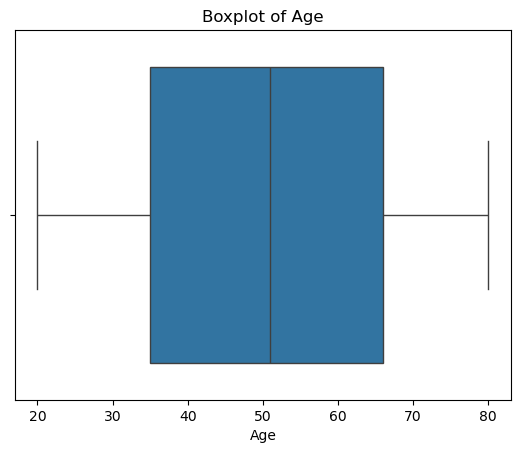

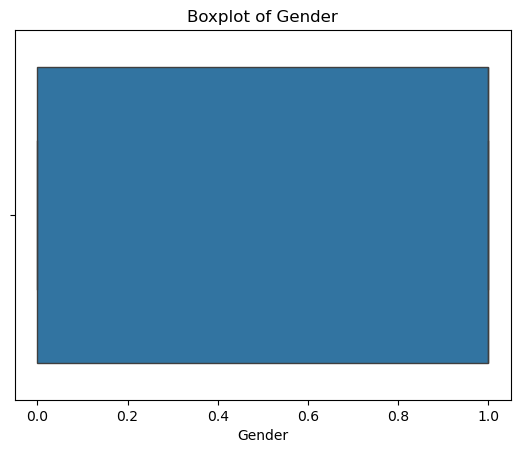

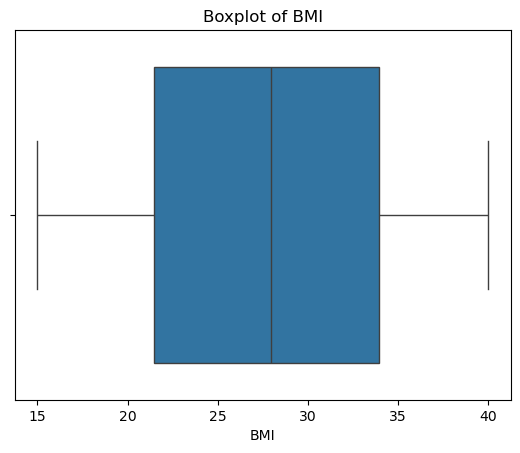

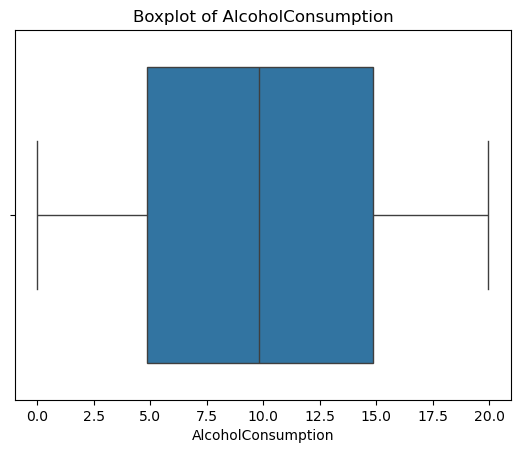

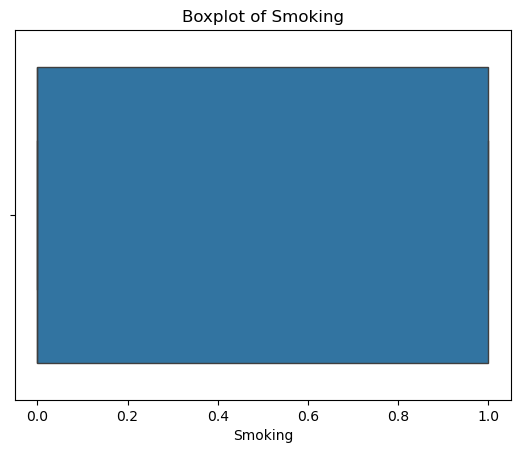

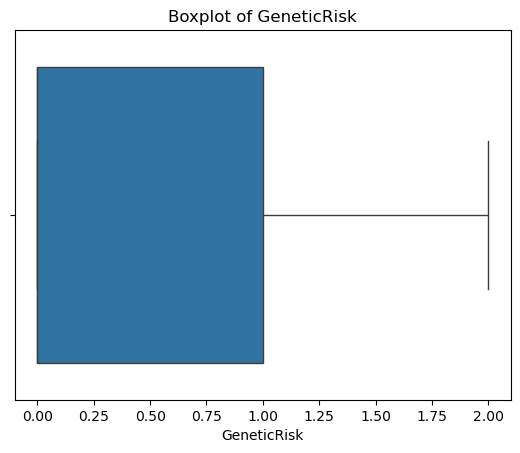

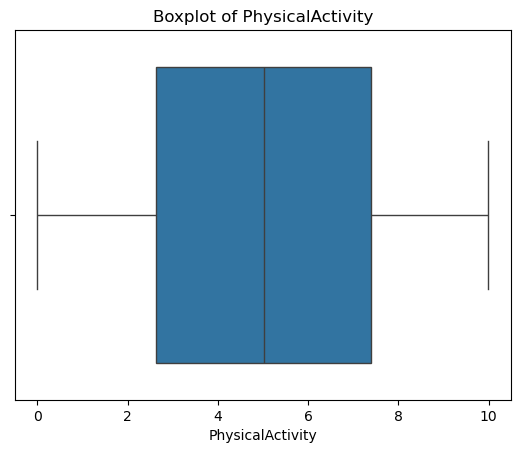

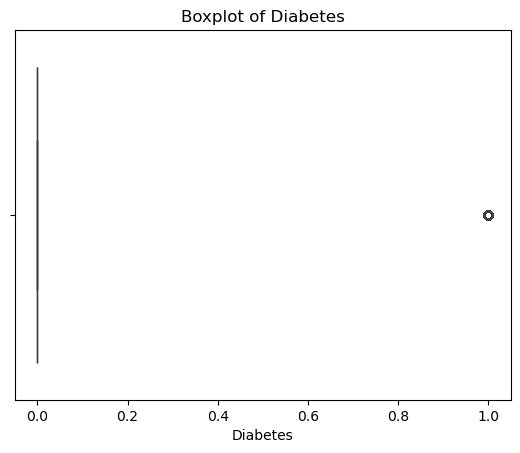

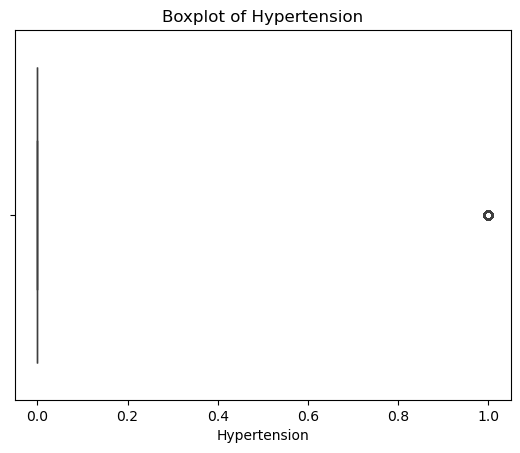

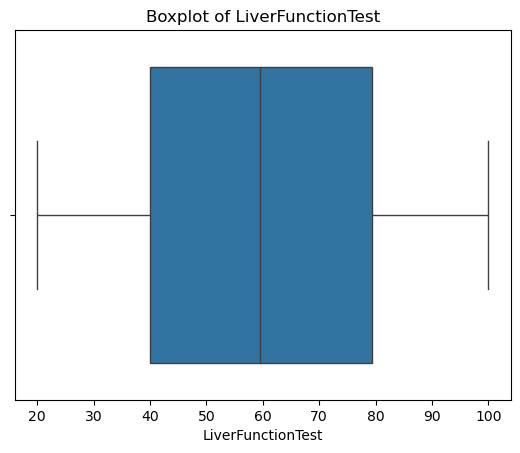

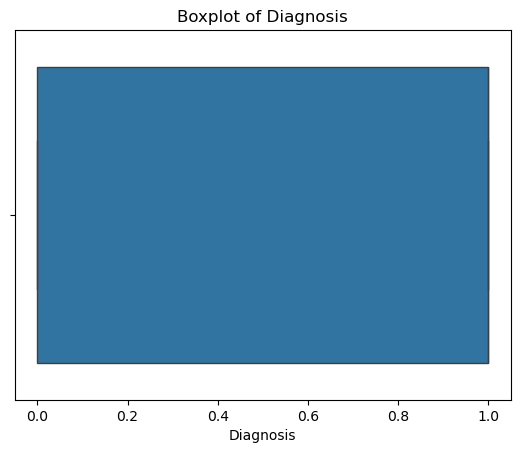

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    if df[col].dtype != 'object':
        plt.figure()
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

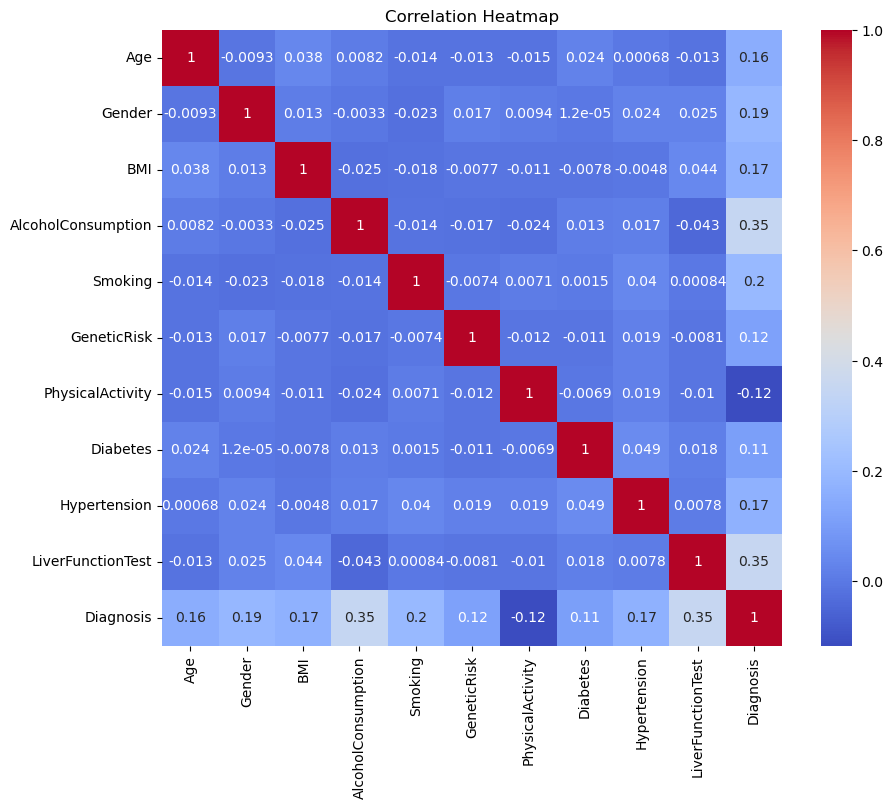

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
x

,Age,Gender,BMI,AlcoholConsumption,Smoking,GeneticRisk,PhysicalActivity,Diabetes,Hypertension,LiverFunctionTest
0,58,0,35.857584,17.272828,0,1,0.658940,0,0,42.734240
1,71,1,30.732470,2.201266,0,1,1.670557,1,0,67.309822
2,48,0,19.971407,18.500944,0,0,9.928308,0,0,63.738956
3,34,1,16.615417,12.632870,0,0,5.630129,0,0,64.555873
4,62,1,16.065830,1.087815,0,1,3.566218,1,0,77.868689
...,...,...,...,...,...,...,...,...,...,...
1695,42,0,38.498295,14.384688,0,1,0.992289,0,0,97.933961
1696,40,0,27.600094,5.431009,0,0,8.390492,0,0,70.260528
1697,38,0,38.730017,6.324302,1,2,9.314222,0,1,56.053370
1698,67,0,35.820798,16.899417,0,2,3.224453,0,0,26.300875


In [16]:
y

0       1
1       1
2       0
3       1
4       1
       ..
1695    1
1696    1
1697    1
1698    1
1699    1
Name: Diagnosis, Length: 1700, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
x_train_scaled = scaler.fit_transform(x_train)

# Transform test data
x_test_scaled = scaler.transform(x_test)

In [19]:
print(y.value_counts())

Diagnosis
1    936
0    764
Name: count, dtype: int64


In [20]:
import pickle

pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(x_train, y_train)

C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:23:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
#EVALUATION
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(x_test_scaled)
    else:
        y_pred = model.predict(x_test)
        
    print(name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print('====================================')

Logistic Regression
[[124  29]
 [ 30 157]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       153
           1       0.84      0.84      0.84       187

    accuracy                           0.83       340
   macro avg       0.82      0.83      0.82       340
weighted avg       0.83      0.83      0.83       340

Random Forest
[[141  12]
 [ 24 163]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.89       153
           1       0.93      0.87      0.90       187

    accuracy                           0.89       340
   macro avg       0.89      0.90      0.89       340
weighted avg       0.90      0.89      0.89       340

XGBoost
[[138  15]
 [ 23 164]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       153
           1       0.92      0.88      0.90       187

    accuracy                           0.89       340
   macro avg     

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc

for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=5)

    print(f"{name}")
    print(f"Cross Validation Scores: {scores}")
    print(f"Average Accuracy: {scores.mean():.4f}")
    print("-" * 50)

Logistic Regression
Cross Validation Scores: [0.80882353 0.8125     0.83455882 0.84558824 0.84191176]
Average Accuracy: 0.8287
--------------------------------------------------
Random Forest
Cross Validation Scores: [0.88602941 0.88235294 0.89338235 0.92279412 0.88970588]
Average Accuracy: 0.8949
--------------------------------------------------


C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:34:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:34:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:34:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:34:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

XGBoost
Cross Validation Scores: [0.875      0.87867647 0.90808824 0.92279412 0.86397059]
Average Accuracy: 0.8897
--------------------------------------------------


C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:34:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:36:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


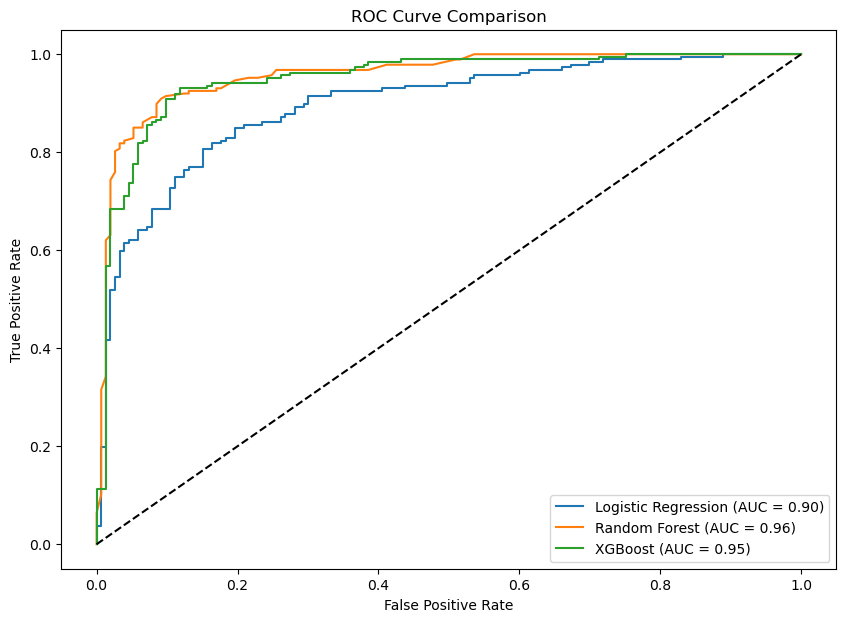

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(x_train, y_train)

    y_prob = model.predict_proba(x_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

pipeline.fit(x_train, y_train)

C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:45:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


In [31]:
import joblib

for name, model in models.items():
    model.fit(x_train, y_train)

    modelname = name.replace(" ", "_") + ".pkl"

    joblib.dump(model, modelname)

C:\Users\abeme\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:40:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
import json

features = list(x.columns)

with open("features.json", "w") as f:
    json.dump(features, f)